# Type Annotations

## Typed Dictionary

- For defining Data Structures

In [1]:
from typing import TypedDict, Union

class Movie(TypedDict):
    name: str
    year: int
    ratings: Union[int,float,str]

    

movie1 = Movie(name = "aaa",year = 2000, ratings=9.0)
movie1
movie2 = Movie(name = "aaa",year = 2000, ratings='5.87')
movie2

{'name': 'aaa', 'year': 2000, 'ratings': '5.87'}

## Union
- Union lets you say that a value can be more than one type
- Type Safety as it can provide hints to help catch incorrect usage

In [2]:
from typing import Union

def square(x: Union[int,float]) -> float:
    return x*x

print(square(5))
print(square(5.0989))


25
25.998781210000004


## Optional

- In the below case `name` can be either String or None
- It cannot be anything else

In [3]:
from typing import Optional

def nice_message(name: Optional[str]) -> None:
    if name is None:
        print('Hey Random person')
    else:
        print(f"Hi there, {name}!")
        
nice_message('Yashar')
nice_message(None)

Hi there, Yashar!
Hey Random person


## Any

- Anything and Everything is allowed!

In [13]:
from typing import Any

def print_value(x: Any):
    print(x)

print_value('aa')
print_value(1010)
print_value(1010.36)

aa
1010
1010.36


## lambda Function

- Shortcut to writing small functions

In [5]:
nums = [1,2,3,4]

squares = list(map(lambda x: x * x, nums))
squares

[1, 4, 9, 16]

## Annotated

- provides additional context without affecting the type itself

In [34]:
from typing import Annotated

email = Annotated[str, "this has to be a valid email format!"]

print(email.__metadata__)

('this has to be a valid email format!',)


## Sequence

- To automatically handle the state updates for sequences as by adding new messages to a chat history
- It helps to avoid any list manipulation to the graph node

In [35]:
from typing import Sequence


# Elements

## State

- The state is a **shared data structure** that holds the current information or context of the enitre application
- It's like the application's memory, keeping track of the variables and data that nodes can access and modify as they execute

## Nodes

- They are **individual functions or operations** that perform specific tasks within the graph
- Each node recevies input(often the current state), processes it, and produces an output or an updated state.

## Graph

- A Graph in LangGraph is the **overarching structure** that maps out how different tasks (nodes) are connected and executed.
- It visually represents the workflow, showing the sequence and conditional paths between various operations.

## Edges

- They are the connections between nodes that determine the **flow of execution**
- They tell us which node should be executed next after the current one completes its task.

## Conditional Edges

- These are specialized connections that decide the next node to execute based on **specific conditions** or logic applied to the current state. They are like if-else statements

## Start node

- The Start node is a virtual entry point in LangGraph, marking where the workflow begins. It doesnt perform any operations itself but serves as the designated starting position for the graph's execution.

## End node

- It is the conclusion of the workflow in LangGraph and the graph's excution stops completely.

## Tools

- They are specialized functions our utilities that  nodes can utilize to perform specific taks such as fetching data from an API
- Tools are fucntionalities used within nodes.

## ToolNode

- Is just a special kind of node whose main job is to run a tool.
- It connects the tool's output back into the state, so other nodes can use that information.

## StateGraph

- Is a **class** in LangGraph used to build and compile the graph structure.
- It manages the nodes, edges, and the overall state, ensuring that workflow operates in a unified way and the data flows correctly between components.
- a **StateGraph** defines the structure and flow of the workflow.

## Runnable

- A **Runnable** in LangGraph is a standardized, executable component that performs a specific task within an AI workflow.
- it serves as a fundamental building block, allowing for us to create modular systems.

- Node in LangGraph recieves a State, while Runnable can perform multiple operations.
- **Runnables** can be combined to create sophisticated AI workflows.

## Messages

`Human Message` : Represents input from a user.

`System Message`: used to provide instructions or context to the model.

`Function Message`: Represents the result of a function call.

`AI Message`: Represents responses generated oby AI models.

`Tool Message`: Similar to Function Message, but specific to tool usage.


# Graph I

In [6]:
from typing import Dict, TypedDict
from langgraph.graph import StateGraph

In [7]:
class AgentState(TypedDict):
    message: str

def greeting_node(state: AgentState) -> AgentState:
    """Simple node that adds a greeting message to the state"""

    state['message'] = "Hey" + state['message'] + ", how is your day going?"

    return state


In [8]:
graph = StateGraph(AgentState)

graph.add_node("greeter",greeting_node)

graph.set_entry_point('greeter')
graph.set_finish_point('greeter')


app = graph.compile()

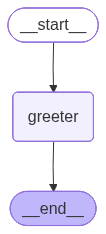

In [9]:
app

In [10]:
result = app.invoke({'message': 'Yashar'})
result['message']

'HeyYashar, how is your day going?'

In [11]:
result

{'message': 'HeyYashar, how is your day going?'}

# Graph II

In [12]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

In [13]:
class AgentState(TypedDict):
    values: List[int]
    name: str
    results: str
    operation: str
    

In [14]:
def process_values(state: AgentState) -> AgentState:
    """this function process handles multiple different inputs"""
    if state['operation'] == '+':
        state['values'] = sum(state['values'])
    else:
        count = state['values'][0]
        for value in state['values'][1:]:
            count *= value
        state['values'] = count
    state['results'] = f"Hi {state['name']}, your result is: {state['values']}"
    return state

In [15]:
graph = StateGraph(AgentState)

graph.add_node('processor', process_values)
graph.set_entry_point('processor') # Set the starting node
graph.set_finish_point('processor') # Set the ending node
app = graph.compile()

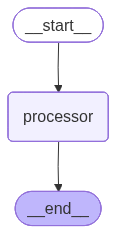

In [16]:
app

In [17]:
result = app.invoke({'values': [1,2,3,4,4],'name':'Yashar','operation': '+'})

In [18]:
print(result['results'])

Hi Yashar, your result is: 14


In [19]:
values = [1,2,3,4,5]

result = list(map(lambda x: x*x, values))
result

[1, 4, 9, 16, 25]

In [21]:
from functools import reduce
import operator

values = [1, 2, 3, 4,5]
result = reduce(operator.mul, values)

print(result)  # Output: 24

120


In [22]:
values = [1,2,3,4,5]

count = values[0]

for value in values:
    count *= value

print(count)

120


# Graph III

In [23]:
from typing import TypedDict
from langgraph.graph import StateGraph

In [24]:
class AgentState(TypedDict):
    name: str
    age: int
    final : str

In [25]:
def first_node(state: AgentState) -> AgentState:
    """This is the first node of our sequence"""

    state['final'] = f"Hi, {state['name']}"
    return state

def second_node(state: AgentState) -> AgentState:
    """This is the second node of our sequence"""

    state['final'] = state['final'] + f"You are {state['age']} years old."

    return state



In [26]:
graph = StateGraph(AgentState)

graph.add_node('1st node', first_node)
graph.add_node('2nd node', second_node)

graph.set_entry_point('1st node')

graph.add_edge('1st node','2nd node')
graph.set_finish_point('2nd node')
app = graph.compile()

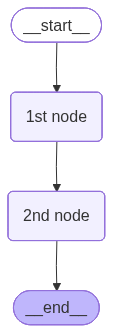

In [27]:
app

In [28]:
result = app.invoke({'name':'yashar','age':20})
print(result['final'])

Hi, yasharYou are 20 years old.


In [29]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

In [30]:
class StateAgent(TypedDict):
    name: str
    age: int
    skills: List[str]
    result: str
    

In [31]:
def first_node(state: StateAgent) -> StateAgent:
    """This is the first node"""
    state['result'] = f"Hi {state['name']}, Hope U R well!\nWelcome to langGraph...\n"
    return state

def second_node(state: StateAgent) -> StateAgent:
    """This is the 2nd node related to Age"""
    state['result'] = state['result'] + f"You are {state['age']} years old.\n"

    return state

def third_node(state: StateAgent) -> StateAgent:
    """This is the 3rd node related to skills"""
    state['skills'] = ", ".join(state['skills'])
    state['result'] = state['result'] + f"You have skills in {state['skills']} !!!"

    return state

In [32]:
graph = StateGraph(StateAgent)

graph.add_node('first_node',first_node)
graph.add_node('second_node',second_node)
graph.add_node('third_node',third_node)

graph.set_entry_point('first_node')
graph.add_edge('first_node','second_node')
graph.add_edge('second_node','third_node')

graph.set_finish_point('third_node')

app = graph.compile()

In [33]:
result = app.invoke({'age':26,'name':'Yashar','skills':['ML','AI','LangGraph']})

In [34]:
result.get('result')

'Hi Yashar, Hope U R well!\nWelcome to langGraph...\nYou are 26 years old.\nYou have skills in ML, AI, LangGraph !!!'

# Graph IV


In [39]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [44]:
class AgentState(TypedDict):
    number1: int
    operation: str
    number2: int
    finalNumber: int

In [45]:
def adder(state: AgentState) -> AgentState:
    """This node adds the 2 numbers"""
    state['finalNumber'] = state['number1'] + state['number2']

    return state

def subtractor(state: AgentState) -> AgentState:
    """This node subtract the 2 numbers"""
    state['finalNumber'] = state['number1'] - state['number2']

    return state

def decide_next_node(state: AgentState) -> AgentState:
    """This node will select the next node of the graph"""

    if state['operation'] == '+':
        return "addition_operation"
    
    elif state['operation'] == '-':
        return 'subtraction_operation'
    
    


In [48]:
graph = StateGraph(AgentState)

graph.add_node('add_node',adder)
graph.add_node('subtract_node',subtractor)
# graph.add_node('router',decide_next_node) this line of code wont work!!! we should use lambda function for the router
graph.add_node('router',lambda state:state) # this means that our input state is our output state. This is our passthrough fucntion. The input and output are the same

graph.add_edge(START, 'router')

graph.add_conditional_edges(
    'router',
    decide_next_node,
    {
        'addition_operation': 'add_node',
        'subtraction_operation':'subtract_node'
    }
)


graph.add_edge('add_node', END)
graph.add_edge('subtract_node', END)


app = graph.compile()

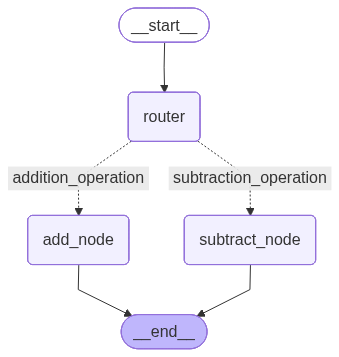

In [49]:
app

In [58]:
result1 = app.invoke(AgentState(number1=100, operation='+', number2=90))
result1['finalNumber']

190

In [64]:
# Exercise

from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class AgentState(TypedDict):
    number1 : int
    number2 : int
    operation1 : str
    finalNumber1 : int
    number3 : int
    number4 : int
    operation2 : str
    finalNumber2 : int

def adder1(state: AgentState) -> AgentState:
    """This function add two numbers"""
    state['finalNumber1'] = state['number1'] + state['number2']

    return state

def subtractor1(state: AgentState) -> AgentState:
    """This function subtract two numbers"""

    state['finalNumber1'] = state['number1'] - state['number2']

    return state

def router1(state: AgentState) -> AgentState:
    """The 1st router..."""

    if state['operation1'] == '+':
        return "addition_operation1"
    elif state['operation1'] == '-':
        return "subtraction_operation1"

def adder2(state: AgentState) -> AgentState:
    """This function add two numbers"""
    state['finalNumber2'] = state['number3'] + state['number4']

    return state

def subtractor2(state: AgentState) -> AgentState:
    """This function subtract two numbers"""

    state['finalNumber2'] = state['number3'] - state['number4']

    return state

def router2(state: AgentState) -> AgentState:
    """The 2nd router..."""

    if state['operation2'] == '+':
        return "addition_operation2"
    elif state['operation2'] == '-':
        return "subtraction_operation2"
    

graph = StateGraph(AgentState)

graph.add_node('router1', lambda state:state)
graph.add_node('adder1',adder1)
graph.add_node('subtractor1',subtractor1)

graph.add_node('router2', lambda state:state)
graph.add_node('adder2',adder2)
graph.add_node('subtractor2',subtractor2)

graph.add_edge(START,'router1')

graph.add_conditional_edges(
    'router1',
    router1,
    {
        "addition_operation1": 'adder1',
        "subtraction_operation1": 'subtractor1'
    }
)


graph.add_edge('adder1','router2')
graph.add_edge('subtractor1','router2')


graph.add_conditional_edges(
    'router2',
    router2,
    {
        "addition_operation2": 'adder2',
        "subtraction_operation2": 'subtractor2'
    }
)


graph.add_edge('adder2',END)
graph.add_edge('subtractor2',END)

app = graph.compile()

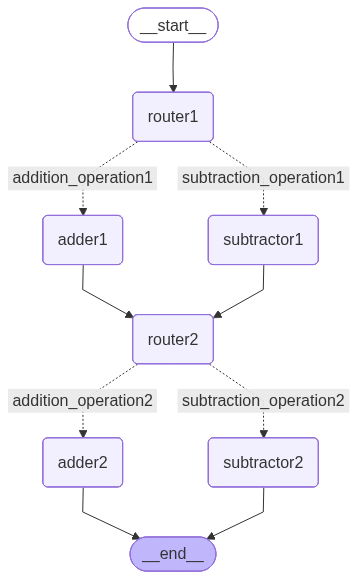

In [65]:
app

In [66]:
result1 = app.invoke(AgentState(number1 = 1,number2 = 2,operation1 = '+',number3 = 3, number4 = 4,operation2 = '-'))

In [67]:
result1

{'number1': 1,
 'number2': 2,
 'operation1': '+',
 'finalNumber1': 3,
 'number3': 3,
 'number4': 4,
 'operation2': '-',
 'finalNumber2': -1}

# Graph V

- Implement looping logic to rout the flow of data back to the nodes
- Create a single conditional edge to handle decision-making and control graph flow
- **Coding up Looping Logic**

In [68]:
from typing import Dict, List, TypedDict
from langgraph.graph import START, END,StateGraph
import random

In [69]:
class AgentState(TypedDict):
    name: str
    number: List[int]
    counter : int
    

In [73]:
def greeting_node(state: AgentState) -> AgentState:
    """Greeting Node"""
    state['name'] = f"Hi there, {state['name']}"
    state['counter'] = 0
    return state

def random_node(state: AgentState) -> AgentState:
    """Generates random number from 0 to 10"""
    state['number'].append(random.randint(0,10))
    state['counter'] += 1
    return state

def should_continue(state: AgentState) -> AgentState:
    """Function to decide what to do next"""
    if state['counter'] < 5:
        print('Entering LOOP', state['counter'])
        return 'loop'
    else:
        return 'exit'


In [79]:
graph = StateGraph(AgentState)

graph.add_node('greeting',greeting_node)
graph.add_node('random',random_node)

graph.add_edge(START,"greeting")

graph.add_edge('greeting','random')


graph.add_conditional_edges(
    'random',
    should_continue, # Action
    {
        'loop': 'random',
        'exit': END
    }
)


app = graph.compile()

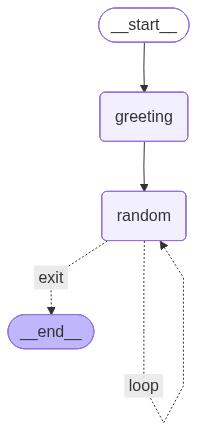

In [80]:
app

In [85]:
app.invoke({'name':'Yashar','number': []})

Entering LOOP 1
Entering LOOP 2
Entering LOOP 3
Entering LOOP 4


{'name': 'Hi there, Yashar', 'number': [6, 8, 7, 10, 2], 'counter': 5}

In [86]:
class GameState(TypedDict):
    player_name: str
    target_number: int
    guesses: List[int]
    attempts: int
    hint: str
    lower_bound: int 
    upper_bound: int 


def setup_node(state: GameState) -> GameState:
    """Initialize the game with a random target number"""
    state["player_name"] = f"Welcome, {state['player_name']}!"
    state["target_number"] = random.randint(1, 20)
    state["guesses"] = []
    state["attempts"] = 0
    state["hint"] = "Game started! Try to guess the number."
    state["lower_bound"] = 1 
    state["upper_bound"] = 20 
    print(f"{state['player_name']} The game has begun. I'm thinking of a number between 1 and 20.")
    return state
def guess_node(state: GameState) -> GameState:
    """Generate a smarter guess based on previous hints"""
    
    possible_guesses = [i for i in range(state["lower_bound"], state["upper_bound"] + 1) if i not in state["guesses"]]
    if possible_guesses:
        guess = random.choice(possible_guesses)
    else:
        
        guess = random.randint(state["lower_bound"], state["upper_bound"])
    
    state["guesses"].append(guess)
    state["attempts"] += 1
    print(f"Attempt {state['attempts']}: Guessing {guess} (Current range: {state['lower_bound']}-{state['upper_bound']})")
    return state
def hint_node(state: GameState) -> GameState:
    """Here we provide a hint based on the last guess and update the bounds"""
    latest_guess = state["guesses"][-1]
    target = state["target_number"]
    
    if latest_guess < target:
        state["hint"] = f"The number {latest_guess} is too low. Try higher!"
        
        state["lower_bound"] = max(state["lower_bound"], latest_guess + 1)
        print(f"Hint: {state['hint']}")
        
    elif latest_guess > target:
        state["hint"] = f"The number {latest_guess} is too high. Try lower!"
      
        state["upper_bound"] = min(state["upper_bound"], latest_guess - 1)
        print(f"Hint: {state['hint']}")
    else:
        state["hint"] = f"Correct! You found the number {target} in {state['attempts']} attempts."
        print(f"Success! {state['hint']}")
    
    return state
def should_continue(state: GameState) -> str:
    """Determine if we should continue guessing or end the game"""
    
    # There are 2 end conditions - either 7 is reached or the correct number is guessed
    
    latest_guess = state["guesses"][-1]
    if latest_guess == state["target_number"]:
        print(f"GAME OVER: Number found!")
        return "end"
    elif state["attempts"] >= 7:
        print(f"GAME OVER: Maximum attempts reached! The number was {state['target_number']}")
        return "end"
    else:
        print(f"CONTINUING: {state['attempts']}/7 attempts used")
        return "continue"
graph = StateGraph(GameState)
graph.add_node("setup", setup_node)
graph.add_node("guess", guess_node)
graph.add_node("hint_node", hint_node)  


graph.add_edge("setup", "guess")
graph.add_edge("guess", "hint_node")  


graph.add_conditional_edges(
    "hint_node", 
    should_continue,
    {
        "continue": "guess",
        "end": END
    }
)

graph.set_entry_point("setup")
app = graph.compile()

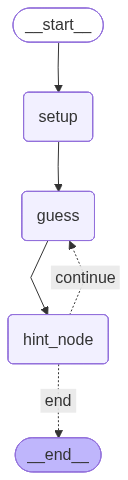

In [87]:
app

In [88]:
result = app.invoke({"player_name": "Student", "guesses": [], "attempts": 0, "lower_bound": 1, "upper_bound": 20})

Welcome, Student! The game has begun. I'm thinking of a number between 1 and 20.
Attempt 1: Guessing 16 (Current range: 1-20)
Hint: The number 16 is too high. Try lower!
CONTINUING: 1/7 attempts used
Attempt 2: Guessing 1 (Current range: 1-15)
Hint: The number 1 is too low. Try higher!
CONTINUING: 2/7 attempts used
Attempt 3: Guessing 13 (Current range: 2-15)
Hint: The number 13 is too low. Try higher!
CONTINUING: 3/7 attempts used
Attempt 4: Guessing 15 (Current range: 14-15)
Hint: The number 15 is too high. Try lower!
CONTINUING: 4/7 attempts used
Attempt 5: Guessing 14 (Current range: 14-14)
Success! Correct! You found the number 14 in 5 attempts.
GAME OVER: Number found!


# Agent I

In [1]:
from typing import TypedDict, List
from langchain_core.messages import HumanMessage
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
import os

In [2]:
env_path = r'C:\Users\Yashar\trip_planner\.env'
load_dotenv(dotenv_path=env_path)
api_key=os.getenv("GROQ_API_KEY")


In [4]:
class AgentState(TypedDict):
    messages: List[HumanMessage]

llm = ChatGroq(model ='llama-3.3-70b-versatile',api_key=api_key)

In [5]:
def process(state: AgentState) -> AgentState:
    response = llm.invoke(state['messages'])
    print(f"\nAI: {response.content}")
    return state


In [6]:
graph = StateGraph(AgentState)
graph.add_node('process', process)
graph.add_edge(START,'process')
graph.add_edge('process',END)
app = graph.compile()

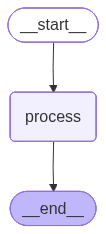

In [7]:
app

In [9]:
user_input = input("Enter: ")
while user_input != 'exit':

    app.invoke({'messages': [HumanMessage(content=user_input)]})
    user_input = input("Enter: ")


AI: 2 + 2 = 4.

AI: As my knowledge cutoff is March 2023, I'll provide you with the latest news about Iran up to that point. Please note that there may have been developments since then.

1. **Protests and Human Rights**: The protests in Iran, which started in September 2022 after the death of Mahsa Amini, a 22-year-old woman who was detained by the morality police, continued into 2023. The protests were met with a crackdown by the government, resulting in hundreds of deaths and thousands of arrests.
2. **Nuclear Program**: Iran's nuclear program remained a key concern for the international community. In 2022, the International Atomic Energy Agency (IAEA) reported that Iran had increased its uranium enrichment to 60%, which is close to the 90% needed for a nuclear bomb. The US and other countries have been trying to revive the 2015 nuclear deal, known as the Joint Comprehensive Plan of Action (JCPOA).
3. **Drones and Military**: Iran has been accused of providing drones to Russia for 

# Agent II

* Fix the memory problem
* Using both HumanMessage and AIMessage

1- The problem with this method is that if we run the program again, the memory will be wiped out.
* Solution --> we can save the chat in a text file.
2- The content keeps getting longer and longer, which can cause cost and so many tokens.
* Solution --> remove the first messages, because the latest ones are the most important

In [10]:
import os
from typing import TypedDict, List, Union
from langchain_core.messages import HumanMessage, AIMessage
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

In [1]:
load_dotenv(dotenv_path=env_path)
api_key=os.getenv("GROQ_API_KEY")


NameError: name 'load_dotenv' is not defined

In [22]:
class AgentState(TypedDict):
    messages : List[Union[HumanMessage,AIMessage]] # this method allow us to store both Human and AI message
    # messages_ai : List[AIMessage] # this method works but it's longer

llm = ChatGroq(model ='llama-3.3-70b-versatile',api_key=api_key)
llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x000002162DD95F10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002162C038AD0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

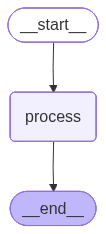

In [ ]:
def process(state: AgentState) -> AgentState:
    """This node solves the request your input"""
    response = llm.invoke(state['messages'])

    state['messages'].append(AIMessage(content=response.content))
    print(f"\nAI: {response.content}")
    print('CURRENT STATE: ', state['messages']) # this print statement act like a snapshot
    return state

graph = StateGraph(AgentState)
graph.add_node('process',process)
graph.add_edge(START,'process')
graph.add_edge('process',END)
agent = graph.compile()
agent

In [25]:
conversation_history = []
user_input = input('Enter: ')
while user_input != 'exit':
    conversation_history.append(HumanMessage(content=user_input))
    result = agent.invoke({'messages': conversation_history}) # the entire conversation history is sent not just the current HumanMessage

    # print(result['messages'])
    conversation_history = result['messages'] # then we replace the conversation history with the result messages
    user_input = input("Enter: ")


AI: Hello Yashar, it's nice to meet you. I hope you're doing well. How's your day going so far? Is there anything I can help you with or would you like to chat?

AI: You're 26 years old, Yashar. You told me that when we first started chatting.

AI: That's nice to know, Yashar. It sounds like you have a strong connection to your roots. Iran is a beautiful country with a rich history and culture. Does your mom still live in Iran, and do you get to visit her often or keep in touch through phone calls or messaging apps?

AI: You're 26 years old, Yashar. We discussed that earlier.

AI: Your mother's name is Taraneh, and she's based in Iran.


In [26]:
conversation_history

[HumanMessage(content='Hi my name is yashar and I am 26 years old', additional_kwargs={}, response_metadata={}),
 AIMessage(content="Hello Yashar, it's nice to meet you. I hope you're doing well. How's your day going so far? Is there anything I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={}),
 HumanMessage(content='How old I am ?', additional_kwargs={}, response_metadata={}),
 AIMessage(content="You're 26 years old, Yashar. You told me that when we first started chatting.", additional_kwargs={}, response_metadata={}),
 HumanMessage(content="my mother's name is Taraneh and she is based in Iran.", additional_kwargs={}, response_metadata={}),
 AIMessage(content="That's nice to know, Yashar. It sounds like you have a strong connection to your roots. Iran is a beautiful country with a rich history and culture. Does your mom still live in Iran, and do you get to visit her often or keep in touch through phone calls or messaging apps?", additional_kwa

# Agent III

**React Agent** --> Reasoning and Acting Agent

In [44]:
from typing import Annotated, Sequence, TypedDict
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage # the foundational class fro all message types in LangGraph
from langchain_core.messages import ToolMessage # Passes data back to LLM after it calls a tool such as the content and the tool_call_id
from langchain_core.messages import SystemMessage # Message for providing instructions to the LLM
from langchain_groq import ChatGroq
from langchain_core.tools import tool
from langgraph.graph.message import add_messages # it is a reducer function, without a reducer, updates would have replaced the existing value entirely. It tells us how to merge new data into the current state.
from langgraph.graph import StateGraph, END,START
from langgraph.prebuilt import ToolNode

In [2]:
load_dotenv(dotenv_path=env_path)
api_key = os.getenv('GROQ_API_KEY')


NameError: name 'load_dotenv' is not defined

In [46]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages] # Here it says to append the message instead of replacing it. the add_messages here is the metadata.


In [74]:
# for building a tool we use decorator @

@tool
def add(a: int, b: int):
    """This is an addition function that addes two numbers together""" # If we remove the docstring here we get an error.otherwise the graph wont work.
    return a + b

@tool
def multiply(a: float, b:float):
    """This a multiplication function that multiplies two numbers together"""

    return a * b

tools = [add,multiply]

model = ChatGroq(model ='llama-3.3-70b-versatile',api_key=api_key).bind_tools(tools) # with the help of bind_tools we are telling the model that we have tools to use

In [75]:
def model_call(state: AgentState) -> AgentState:
    system_prompt = SystemMessage(content='You are an AI assisstant please answer my query to the best of your ability.') # this is the system message which we are asking

    response = model.invoke([system_prompt] + state['messages']) # In order to add the query from user we use + state['messages'] 
    return {'messages':[response]}


In [76]:
def should_continue(state: AgentState) -> AgentState:
    messages = state['messages']
    last_message = messages[-1]
    if not last_message.tool_calls:     # we are gonna recieve the last message and see if any tool needed to run or not
        return "end"
    else:
        return "continue"

In [77]:
graph = StateGraph(AgentState)
graph.add_node('agent', model_call)
graph.add_edge(START,'agent')

tool_node = ToolNode(tools = tools)
graph.add_node('tools',tool_node)

graph.add_conditional_edges(
    'agent',
    should_continue,
    {
        'continue':'tools',
        'end':END,
    },
)


graph.add_edge('tools','agent')

app = graph.compile()

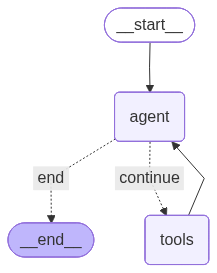

In [78]:
app

In [79]:

def print_stream(stream):
    for s in stream:
        message = s['messages'][-1]
        if isinstance(message,tuple):
            print(message)
        else:
            message.pretty_print()

In [80]:
inputs = {'messages': [('user',"Add 3 + 7 then multiply it by 0.5 .")]}
print_stream(app.stream(inputs, stream_mode='values'))

================================ Human Message =================================

Add 3 + 7 then multiply it by 0.5 .
================================== Ai Message ==================================
Tool Calls:
  add (kdkdfatcy)
 Call ID: kdkdfatcy
  Args:
    a: 3
    b: 7
  multiply (gypxx8eg8)
 Call ID: gypxx8eg8
  Args:
    a: 10
    b: 0.5
================================= Tool Message =================================
Name: multiply

5.0
================================== Ai Message ==================================

The result of adding 3 + 7 is 10, then multiplying 10 by 0.5 results in 5.0.


# Agent IV

**DRAFTER**


- reduce time on drafting documents like emails.
- need human collaboration in the system
- when the human is happy is the agent should stop.


In [81]:
from typing import Annotated, Sequence, TypedDict
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage, SystemMessage
from langchain_groq import ChatGroq
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode

In [3]:
load_dotenv(dotenv_path=env_path)
api_key = os.getenv('GROQ_API_KEY')


NameError: name 'load_dotenv' is not defined

In [83]:
# This is the global variable to store document content
document_content = ""

In [84]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseException],add_messages]


In [85]:
@tool
def update(content:str) -> str:
    """Updates the document with the  provided content"""
    global document_content
    document_content = content
    return f"Document has been updated successfully! The current content is: \n{document_content}"

@tool
def save(filename: str) -> str:
    """Save the current document to a text file and finish the process.
    Args:
        filename: Name of the text file
    """
    if not filename.endswith('.txt'):
        filename = f"{filename}.txt"

    try:
        with open(filename, 'w') as file:
            file.write(document_content)
        print(f"\nDocument has been saved to: {filename}")
        return f"Document has been saved successfully to '{filename}'."
    except Exception as e:
        return f"Error Saving document: {str(e)}"

    

In [ ]:
tools = [update, save]

model = ChatGroq(api_key=api_key, model='llama-3.3-70b-versatile').bind_tools(tools=tools)


In [91]:
def agent(state: AgentState) -> AgentState:
    system_prompt = SystemMessage(content=f"""
    You are Drafter, a helpful writing assistant. You are going to help the user update and modify the documents.

    - If the user wants to update or modify content, use the 'update' tool with the complete updated content.
    - If the user wants to save and finish, you need to use the 'save' tool.
    - Make sure to always show the current document state after modifications.

    The current document is: {document_content}                              
                                  """)
    
    if not state['messages']:
        user_input = "I'm ready to help you update a document. What would you like to create?"
        user_message = HumanMessage(content=user_input)
    else:
        user_input = input("\nWhat would you like to do with the document? ")
        print(f"\n USER: {user_input}")
        user_message = HumanMessage(content=user_input)
    
    all_messages = [system_prompt] + list(state["messages"]) + [user_message]

    response = model.invoke(all_messages)

    print(f"\nAI: {response.content}")
    if hasattr(response, 'tool_calls') and response.tool_calls:
        print(f"USING TOOLS: {[tc['name'] for tc in response.tool_calls]}")
    
    return {'messages': list(state['messages']) + [user_message, response]}


def should_continue(state: AgentState) -> str:
    """Determine if we continue or end the conversation"""

    messages = state['messages']

    if not messages:
        return "continue"

    # This looks for the recent tool message...
    for message in reversed(messages):
        #... and checks if this is a ToolMessage resulting from save
        if (isinstance(message,ToolMessage) and
            "saved" in message.content.lower() and
             "document" in message.content.lower()):
            return "end" # goes to the end edge which leads to the endpoint
    return "continue"

def print_message(messages):
    """"Function I made to print the messages in a more readable format"""
    if not messages:
        return
    
    for message in messages[-3:]:
        if isinstance(message, ToolMessage):
            print(f"\nTOOL RESULT: {message.content}")

            

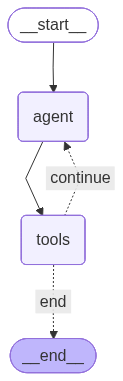

In [92]:
graph = StateGraph(AgentState)

graph.add_node('agent', agent)
graph.add_edge(START,'agent')

graph.add_node('tools',ToolNode(tools))

graph.add_edge('agent','tools')

graph.add_conditional_edges(
    'tools',
    should_continue,
    {
        "continue":"agent",
        "end": END
    }
)

app = graph.compile()

app


In [94]:
def run_document_agent():
    print("\n==== DRAFTER AGENT ====")

    state = {"messages": []}

    for step in app.stream(state, stream_mode='values'):
        if 'messages' in step:
            print(step['messages'])

    print("\n ==== DRAFTER FINISHED ====")

if __name__ == '__main__':
    run_document_agent()


==== DRAFTER AGENT ====
[]

AI: 
USING TOOLS: ['update']
[HumanMessage(content="I'm ready to help you update a document. What would you like to create?", additional_kwargs={}, response_metadata={}, id='ab2bcc1d-c7e8-4080-a082-90891b39fb61'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'n15yq87yc', 'function': {'arguments': '{"content":"This is a new document. Let\'s create a story about a character who goes on a journey."}', 'name': 'update'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 412, 'total_tokens': 444, 'completion_time': 0.102862294, 'prompt_time': 0.055027861, 'queue_time': 0.279312814, 'total_time': 0.157890155}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--1379a374-1245-40e5-827f-b166173a0dde-0', tool_calls=[{'name': 'update', 'args': {'content': "This is a new document. Let's 

In [95]:
document_content

"This is a new document. Let's create a story about a character who goes on a journey. Dear Tom, I am writing to inform you that I will be unable to come to work as I am currently unwell. I apologize for any inconvenience this may cause and will make sure to catch up on any missed work as soon as I am feeling better."

# Agent V

In [2]:
from dotenv import load_dotenv
import os
from langgraph.graph import StateGraph, START, END
from typing import Annotated, TypedDict, Sequence
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, ToolMessage
from operator import add as add_messages
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_core.tools import tool

In [4]:
env_path = r'C:\Users\Yashar\trip_planner\.env'
load_dotenv(dotenv_path=env_path)
api_key = os.getenv('GROQ_API_KEY')


NameError: name 'load_dotenv' is not defined

In [8]:
llm = ChatGroq(api_key=api_key, model='llama-3.3-70b-versatile', temperature=0) # Temperature is how stochastic you want the model to be. it controls the hallucination.
model_name = "sentence-transformers/all-MiniLM-L6-v2"
embeddings = HuggingFaceEmbeddings(model_name=model_name)
embeddings

HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [9]:
%pwd

'c:\\Users\\Yashar\\trip_planner\\notebook'

In [10]:
pdf_path = r'C:\Users\Yashar\trip_planner\Nuffic Agreement - Yashar Ghaffari.pdf'
if not os.path.exists(pdf_path):
    raise FileNotFoundError(f"PDf file not found {pdf_path}")

In [11]:
pdf_loader = PyPDFLoader(pdf_path)

In [16]:
try:
    pages = pdf_loader.load()
    print(f"PDF has been loaded and has {len(pages)} pages")
except Exception as e:
    print(f"Error loading PDF: {e}")
    raise

PDF has been loaded and has 4 pages


In [17]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1000,
    chunk_overlap = 200
)

In [ ]:
pages_split = text_splitter.split_documents(pages)


In [20]:
presist_directory = r'C:\Users\Yashar\trip_planner'
collection_name = 'Internship_NUFFIC'

if not os.path.exists(presist_directory):
    os.makedirs(presist_directory)
else:
    print('OK')

OK


In [21]:
try:
    vectorstore = Chroma.from_documents(
        documents=pages_split,
        embedding=embeddings,
        persist_directory=presist_directory,
        collection_name=collection_name
    )
    print("ChromaDB vectore store created")
except Exception as e:
    print(f'Error setting up ChromaDB: {str(e)}')
    raise

ChromaDB vectore store created


In [22]:
retriever = vectorstore.as_retriever(
    search_type = 'similarity',
    search_kwargs = {'k':5} # K is the amount of chunks to return
)

@tool
def retriever_tool(query:str) -> str:
    """
    This tool searches and returns the information from the Internship NUFFIC document
    """

    docs = retriever.invoke(query)

    if not docs:
        return "I found no relevant information in the Internship NUFFIC document"
    
    results = []
    for i,doc in enumerate(docs):
        results.append(f"Document {i+1}: \n{doc.page_content}")

    return "\n\n".join(results)

tools = [retriever_tool]

llm = llm.bind_tools(tools)


In [24]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage],add_messages]

def should_continue(state: AgentState):
    """Check if the last message contains tool calls."""
    result = state['messages'][-1]
    return hasattr(result, 'tool_calls') and len(result.tool_calls) > 0


system_prompt = """"
You are an AI assisstant who answers questions about legal document and mostly related to Internship agreements in Europe for non-eu students.
Use the retriever tool available to answer questions about the Internship NUFFIC agreement data in Europe.
You can make multiple calls if need to look up some information before asking a follow up question.
Please always cite the specific parts of the documents you use in your answers. 
"""
tools_dict = {our_tool.name: our_tool for our_tool in tools} # creating a dictionary for our tools


def call_llm(state: AgentState) -> AgentState:
    """Function to call the LLM with the current state."""

    messages = list(state['messages'])
    messages = [SystemMessage(content=system_prompt)] + messages
    message = llm.invoke(messages)
    return {'messages': [message]}



# Retriever Agent

def take_action(state: AgentState) -> AgentState:
    """Execute tool calls from the LLM's response"""
    tool_calls = state['messages'][-1].tool_calls
    results = []
    for t in tool_calls:
        print(f"Calling Tool: {t['name']} with query: {t['args'].get('query','No query provided')}")

        if not t['name'] in tools_dict:
            print(f"\nTool: {t['name']} not available")
            result = "Incorrect Tool name, please retry and select tool from List of available tools"
        else:
            result = tools_dict[t['name']].invoke(t['args'].get('query',''))
            print(f"Result Length: {len(str(result))}")

        results.append(ToolMessage(tool_call_id = t['id'], name = t['name'], content = str(result)))

    print("Tools Execution Complete. Back to the model!")
    return {'messages': results}


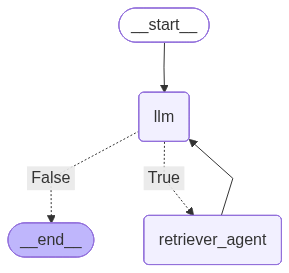

In [25]:
graph = StateGraph(AgentState)
graph.add_node('llm',call_llm)
graph.add_node('retriever_agent',take_action)

graph.add_edge(START,'llm')

graph.add_conditional_edges(
    'llm',
    should_continue,
    {
        True: 'retriever_agent',
        False: END
    }
)

graph.add_edge('retriever_agent','llm')

app = graph.compile()
app

In [26]:
def running_agent():
    print(f"\n==== RAG AGENT ====")

    while True:
        user_input = input("\nWhat is your question: ")
        if user_input.lower() in ['exit','quit']:
            break

        messages = [HumanMessage(content=user_input)]

        result = app.invoke({'messages':messages})

        print("\n==== ANSWER ====")
        print(result['messages'][-1].content)


if __name__ == '__main__':
    running_agent()



==== RAG AGENT ====
Calling Tool: retriever_tool with query: summary of internship agreement
Result Length: 4767
Tools Execution Complete. Back to the model!

==== ANSWER ====
Here is a 3-line summary of the important details of the Internship document: 
The internship agreement is subject to Dutch law and any deviations from the agreement must be made in writing (Article 10). 
The internship period and hours per week are specified in the agreement, and the purpose of the internship is to enable the student to gain practical experience and new knowledge and skills (Article 3). 
The agreement also outlines the terms of termination, including the right of the internship employer and the Dutch educational institution to terminate the agreement under certain circumstances (Article 2 and Article 4).
Calling Tool: retriever_tool with query: working hours per week for non-EU students in Internship NUFFIC document
Result Length: 4340
Tools Execution Complete. Back to the model!
Calling Tool: 